# Wordle Solver: Comparative Evaluation

This notebook implements and evaluates multiple Wordle-solving strategies spanning
heuristic methods, search-based approaches, and reinforcement learning. The goal is to
analyze how different algorithmic paradigms perform in a structured, deterministic,
combinatorial environment, and to understand when additional model complexity leads to
meaningful performance gains.

Wordle can be viewed as a sequential decision problem over a finite hypothesis space,
where each guess partitions the remaining candidate set based on feedback. This structure
naturally supports multiple solution approaches, including heuristic scoring, worst-case
search, expected-value search, and learned policies. This project compares representative
methods from each class under a unified experimental framework.

## Solvers Evaluated

1. **Frequency Heuristic**  
   Scores candidate words using letter frequency statistics, with additional weighting for
   positional matches. This serves as a fast, interpretable baseline but does not explicitly
   reason about future outcomes.

2. **Minimax Partition Solver**  
   For each candidate guess, simulates feedback against all remaining words and selects the
   guess that minimizes the size of the largest resulting partition. This implements a
   classical minimax strategy that optimizes worst-case reduction of the candidate set.

3. **DQN v1 (Pure)**  
   A Deep Q-Network (417→512→512→130) trained end-to-end to map game states to word
   selections. Following Ho (2022), the model uses a factorized output representation to
   score all candidate words. Training uses a multi-stage exploration curriculum over
   18,000 episodes.

4. **DQN v2 (Teacher-Guided / Reward-Shaped)**  
   Extends DQN v1 by incorporating rollout as a teacher policy. Exploration is guided by
   teacher actions, and additional reward is provided for matching teacher decisions. This
   results in a hybrid reinforcement learning / imitation learning setup.

5. **Tabular Q-Learning (Meta-Policy)**  
   Learns a policy over solver strategies rather than individual word guesses. The state is
   defined by simple feedback features (number of green and yellow letters), and actions
   correspond to selecting among predefined heuristics. This approach follows the idea of
   learning strategy selection rather than solving the full problem directly.

6. **Rollout Solver (Expected-Value Search)**  
   Implements one-step lookahead policy improvement over a base heuristic. For each
   candidate guess, complete games are simulated across all remaining words using the base
   policy, and the guess minimizing expected total guesses is selected. Memoization reduces
   the effective state space, making evaluation efficient after initial computation.

## Benchmark

To support both Wordle-style and WordMaster-style gameplay, a unified benchmark was
constructed by merging their vocabularies into a deduplicated, case-normalized set of
2,983 five-letter words.

- All 2,983 words are valid hidden words and valid guesses  
- The target and guess sets are identical (closed vocabulary)  
- The merged list contains all Wordle words plus additional WordMaster-only words  

This design enables unlimited simulation and consistent comparison across all solver
implementations. Because this benchmark differs from the standard Wordle setup used in
prior work (which separates answer and guess vocabularies), published results are included
for qualitative context rather than direct numerical comparison.

## Context from Prior Work

Bertsimas & Paskov (2024) compute an exact optimal Wordle policy via dynamic programming,
achieving:
- **3.421 average guesses**
- **100% win rate**
- **maximum of 5 guesses**

This result serves as a theoretical reference point for evaluating solver performance,
though it is defined on the standard Wordle benchmark.

## References

1. Anderson, B.J. & Meyer, J.G. (2022). *Finding the optimal human strategy for Wordle using maximum correct letter probabilities and reinforcement learning.* arXiv:2202.00557.  
2. Bertsimas, D. & Paskov, A. (2024). *An Exact Solution to Wordle.* Operations Research.  
3. Bhambri, S., Bhattacharjee, A. & Bertsekas, D.P. (2022). *Reinforcement Learning Methods for Wordle: A POMDP/Adaptive Control Approach.* arXiv:2211.10298.  
4. Ho, A. (2022). *Solving Wordle with Reinforcement Learning.* Blog post & Weights & Biases report. https://andrewkho.github.io/wordle-solver/  
5. Liu, C.-L. (2022). *Using Wordle for Learning to Design and Compare Strategies.* IEEE Conference on Games (CoG).  
6. Lokshtanov, D. & Subercaseaux, B. (2022). *Wordle is NP-Hard.* In Fun with Algorithms. arXiv:2203.16713.  
7. Mnih, V. et al. (2015). *Human-level control through deep reinforcement learning.* Nature, 518, 529–533.  

## Setup

In [6]:
# === SETUP - Run once at start ===
import os

# Nuclear reset - delete everything and start fresh
os.chdir("/content")
!rm -rf wordle-ML-project

# Fresh clone
!git clone https://{GITHUB_TOKEN}@github.com/jhffmn82/wordle-ML-project.git

# Get inside the repo
os.chdir("/content/wordle-ML-project")

# Verify we're in the right place
!pwd
!git status
!git log --oneline -3

# Config
!git config user.email "jhoffmn.myAlt1@gmail.com"
!git config user.name "jhffmn82"
!git remote set-url origin https://{GITHUB_TOKEN}@github.com/jhffmn82/wordle-ML-project.git

# Install dependencies
!pip install torch numpy matplotlib tqdm

Cloning into 'wordle-ML-project'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 132 (delta 61), reused 14 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 4.22 MiB | 20.09 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/content/wordle-ML-project
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
f749e71 (HEAD -> main, origin/main, origin/HEAD) rollout cache - 431 states
6d4daed Add files via upload
c372b24 Add files via upload


In [7]:
import sys, os, time, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

sys.path.insert(0, os.getcwd())

# Force reload all project modules (clears cached versions)
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith(('engine', 'solvers')):
        del sys.modules[mod_name]

from engine.wordle_env import WordleGame, load_word_list, get_feedback, filter_words
from engine.state_encoder import encode_state, encode_words_onehot, STATE_DIM
from solvers.frequency_solver import FrequencySolver
from solvers.infogain_solver import InfoGainSolver
from solvers.dqn_solver import DQNNetwork, DQNSolver, ReplayBuffer
from solvers.tabular_q_solver import TabularQSolver, train_tabular_q, STRATEGY_NAMES
from solvers.rollout_solver import RolloutSolver

WORDS = load_word_list()
WORD_ENCODINGS = torch.tensor(encode_words_onehot(WORDS), dtype=torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Loaded {len(WORDS)} words, device: {device}")

Loaded 2983 words, device: cpu


In [8]:
def demo_solver(solver, words=None):
    """Play a few words and show colored results."""
    if words is None:
        words = ["crane", "slink", "nymph", "fuzzy", "vivid"]
    for target in words:
        print(f"\nTarget: {target.upper()}")
        game = WordleGame(target=target, word_list=WORDS)
        solver.reset()
        while not game.is_over():
            guess = solver.get_guess()
            feedback = game.make_guess(guess)
            solver.update(guess, feedback)
            tiles = " ".join(["🟩" if f==2 else "🟨" if f==1 else "⬛" for f in feedback])
            print(f"  Turn {game.turn}: {guess.upper()}  {tiles}")
            if game.is_solved():
                print(f"  Solved in {game.turn} guesses!")
                break
        if not game.is_solved():
            print(f"  Failed! Target was {target.upper()}")

---
## Part 1: Heuristic Solvers
These require no training.

### 1.1 Frequency Heuristic (Original, 2021)

This solver was originally developed in 2021 as a Wordle/WordMaster assistant tool with a
tkinter-based graphical interface. It has been adapted here into a headless implementation
for automated evaluation.

For each candidate word, the solver computes a score based on two components:

- **Letter frequency:** Counts how often each unique letter appears across the remaining
  candidate set.
- **Positional frequency:** Counts how often each letter appears in each specific position
  across the remaining candidate set.

To avoid overweighting repeated letters, scoring is computed using **unique letters only**.
The final score combines both components, weighting positional frequency more heavily:

$$
\text{score}(w)
=
\sum_{\ell \in \text{unique}(w)} \text{freq}(\ell)
+
3 \cdot
\sum_{\ell \in \text{unique}(w)} \text{freq}_{\text{pos}}(\ell, \text{pos}(\ell))
$$

This weighting favors guesses that are more likely to produce **green tiles** (correct
letter and position), rather than only identifying correct letters.

When more than two candidate words remain, the solver also considers **exploration words**
from the full vocabulary. These are words that may not be valid solutions but are expected
to provide high information gain by covering frequent letters or positions, improving
future pruning of the candidate set.

This approach is computationally efficient and performs well in early and mid-game stages,
but does not explicitly reason about worst-case or expected future outcomes.

In [9]:
freq_solver = FrequencySolver()
demo_solver(freq_solver)


Target: CRANE
  Turn 1: CARES  🟩 🟨 🟨 🟨 ⬛
  Turn 2: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 2 guesses!

Target: SLINK
  Turn 1: CARES  ⬛ ⬛ ⬛ ⬛ 🟨
  Turn 2: STONY  🟩 ⬛ ⬛ 🟩 ⬛
  Turn 3: SLUNG  🟩 🟩 ⬛ 🟩 ⬛
  Turn 4: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: NYMPH
  Turn 1: CARES  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: DOILY  ⬛ ⬛ ⬛ ⬛ 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: CARES  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: DOILY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: JUMPY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 4: FUNKY  🟩 🟩 ⬛ ⬛ 🟩
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: CARES  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: DOILY  🟨 ⬛ 🟨 ⬛ ⬛
  Turn 3: HUMID  ⬛ ⬛ ⬛ 🟩 🟩
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


### 1.2 Minimax Partition Solver

For each possible guess, the solver simulates the feedback it would produce against every
remaining candidate word. The candidate set is then partitioned by feedback pattern, where
all words producing the same pattern (i.e., identical colored tile responses) are grouped
together.

The size of each partition represents the number of possible words remaining after that
feedback. The **worst-case outcome** for a guess is the size of its largest partition.

The solver selects the guess that minimizes this worst-case:

$$
g^* = \arg\min_g \max_{\text{feedback}} |S_{t+1}|
$$

This implements a classical **minimax strategy**, ensuring the strongest possible reduction
of the candidate set under the most unfavorable outcome.

The first guess is computed once and cached, since the initial state is fixed. Subsequent
turns are computationally efficient, as the candidate set shrinks rapidly after each guess.

In [10]:
ig_solver = InfoGainSolver()
demo_solver(ig_solver)

Computing best opening guess (one-time cost)...
  Best opener: RAISE (28.2s)

Target: CRANE
  Turn 1: RAISE  🟨 🟨 ⬛ ⬛ 🟩
  Turn 2: GRACE  ⬛ 🟩 🟩 🟨 🟩
  Turn 3: EVENT  🟨 ⬛ ⬛ 🟩 ⬛
  Turn 4: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: SLINK
  Turn 1: RAISE  ⬛ ⬛ 🟩 🟨 ⬛
  Turn 2: SLANT  🟩 🟩 ⬛ 🟩 ⬛
  Turn 3: SLING  🟩 🟩 🟩 🟩 ⬛
  Turn 4: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: NYMPH
  Turn 1: RAISE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: MOLDY  🟨 ⬛ ⬛ ⬛ 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: RAISE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: MOLDY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: APING  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 4: ABACK  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: RAISE  ⬛ ⬛ 🟨 ⬛ ⬛
  Turn 2: NIFTY  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 3: LIVID  ⬛ 🟩 🟩 🟩 🟩
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


---
## Part 2: Curated Word Lists

To identify strong exploratory guesses, the frequency heuristic is run across all target
words, and the selected guesses at each turn are recorded.

Early-game guesses (turns 1–2) are primarily **information-gathering moves**, chosen to
maximize coverage of common letters and positions rather than immediately solve for the
hidden word. These guesses form a high-quality **exploration vocabulary**, useful for
reducing the candidate set as efficiently as possible in the opening stages of the game.

In [11]:
from engine.word_lists import build_curated_lists

set1, set2, set3, turn_words = build_curated_lists()

print(f"\nCurriculum:")
print(f"  Set 1: {len(set1):>5} words (openers + direct seconds)")
print(f"  Set 2: {len(set2):>5} words (+ cascaded thirds)")
print(f"  Set 3: {len(set3):>5} words (+ remaining A/B)")
print(f"  Set 4: {len(WORDS):>5} words (full)")

Building curated word lists...
  Top 5 openers: ['CARES', 'SANER', 'DARES', 'RATES', 'CANES']
  Set 1: 24 words (openers + seconds)
  Set 2: 83 words (+ cascaded thirds)
  Running full solver for turn 1-3 words...
  Set 3: 1309 words (+ remaining A/B)
  Set 4: 2983 words (full)
  Done in 400.4s

Curriculum:
  Set 1:    24 words (openers + direct seconds)
  Set 2:    83 words (+ cascaded thirds)
  Set 3:  1309 words (+ remaining A/B)
  Set 4:  2983 words (full)


---
## Part 3: DQN Training

A Deep Q-Network (DQN) is trained to play Wordle by learning action values for candidate
guesses from an encoded game state. In contrast to heuristic and search-based solvers,
this is an end-to-end function approximation approach: the model must learn useful word
selection behavior from interaction data rather than explicit symbolic reasoning.

### Architecture

Following Ho (2022), the model uses:

- **Input:** 417-dimensional state vector encoding board state and letter information  
- **Hidden layers:** fully connected MLP (512 → 512) with ReLU activation  
- **Output:** 130-dimensional vector (26 letters × 5 positions)  
- **Action selection:** candidate words are encoded as 130-dimensional vectors and scored
  via dot product with the network output  

This factorized representation reduces the dimensionality of the action space, but assumes
that word quality can be approximated as a sum of letter-position contributions.

---

### Core Challenge

Direct DQN training in this environment is difficult due to:

- large action space (2,983 words)  
- inefficient random exploration  
- delayed reward signals  
- need to approximate structured, rule-based filtering  

These challenges are consistent with Ho (2022), who reports that DQN struggled on the full
Wordle problem, and with known instability issues in DQN (Mnih et al., 2015).

---

### Curated Exploration Curriculum

To improve exploration efficiency, training uses a curriculum derived from the frequency
solver’s decision paths across the 2,983-word benchmark:

- **Set 1 (~24 words):** strong openers and immediate follow-ups  
- **Set 2 (~83 words):** Set 1 plus next-level expansions  
- **Set 3 (~1,309 words):** words commonly used in turns 1–3  
- **Set 4 (2,983 words):** full vocabulary  

Each set is cumulative, ensuring that high-value exploratory words remain available
throughout training.

---

### Training Phases

- **Phase 1 (200 episodes):** basic feedback patterns  
- **Phase 2 (800 episodes):** expanded pattern coverage  
- **Phase 3 (5,000 episodes):** common trajectories  
- **Phase 4 (12,000 episodes):** full-vocabulary generalization  

This staged training approach is inspired by Ho (2022), who similarly scales training
across increasing vocabulary sizes.

---

### Exploration Schedule

- Epsilon fixed at **0.9** during Phases 1–3  
- Decays from **0.9 → 0.0** during Phase 4  
- Final training runs under pure exploitation  

---

### Reward Structure

The reward function provides dense intermediate feedback and encourages fast solutions:

- **Green letter:** +5  
- **Yellow letter:** +2  
- **Win:** +15 plus a speed bonus based on remaining turns  
- **Loss:** negative reward scaled by training phase  

This reward design follows the general approach used in Anderson & Meyer (2022), where
reinforcement learning is guided by both intermediate feedback signals and final task
success.

---

### Training Stability

Training uses standard DQN stabilization techniques:

- **Experience replay** (large replay buffer)  
- **Target network** (periodic updates)  
- **Checkpointing** for monitoring performance  

These techniques follow Mnih et al. (2015), which established replay buffers and target
networks as core methods for stabilizing deep Q-learning.

---

### Interpretation

This setup evaluates whether a neural network can learn an effective Wordle policy through
function approximation alone. In this project, pure DQN underperforms search-based methods,
suggesting that problems with strong symbolic structure and exact filtering logic may be
better addressed with explicit search rather than approximate value learning.

In [12]:
def compute_reward(feedback, solved, failed, turn=0, explore_ratio=1.0):
    reward = 0.0
    for fb in feedback:
        if fb == 2: reward += 5.0
        elif fb == 1: reward += 2.0
    if solved:
        reward += 15.0 + (6 - turn) * 3.0
    elif failed:
        reward -= 25.0 * (explore_ratio ** 2)
    return reward

In [13]:
def train_dqn(num_episodes=18000, batch_size=64, gamma=0.95,
              lr=0.001, target_update=500, log_interval=1000,
              exploration_sets=None,
              phase_episodes=None):
    if exploration_sets is None:
        exploration_sets = [WORDS]
    if phase_episodes is None:
        phase_episodes = [200, 800, 5000, 12000]

    word_to_idx = {w: i for i, w in enumerate(WORDS)}
    policy_net = DQNNetwork().to(device)
    target_net = DQNNetwork().to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=100000)
    word_enc = WORD_ENCODINGS.to(device)

    history = {"episode": [], "win_rate": [], "avg_guesses": [], "epsilon": []}
    recent_wins = []
    recent_guesses = []
    epsilon = 0.9

    # Epsilon decays from 0.9 to 0 over first 8000 episodes of phase 4
    # leaving 4000 episodes of pure exploitation
    epsilon_decay = 0.99915  # 0.9 * 0.99915^8000 ≈ 0.001

    # Build merged sets: each phase includes all previous
    merged_sets = []
    accumulated = set()
    for s in exploration_sets:
        accumulated = accumulated | set(s)
        merged_sets.append(sorted(accumulated))

    for phase in range(len(exploration_sets)):
        explore_words = merged_sets[phase]
        explore_set = set(explore_words)
        explore_ratio = len(explore_words) / len(WORDS)
        phase_start = sum(phase_episodes[:phase])
        phase_end = phase_start + phase_episodes[phase]
        is_final_phase = (phase == len(exploration_sets) - 1)

        print(f"\n--- Phase {phase+1}: explore from {len(explore_words)} words, "
              f"{phase_episodes[phase]} episodes ({phase_start}-{phase_end}) ---")

        for episode in range(phase_start, phase_end):
            target = random.choice(WORDS)
            game = WordleGame(target=target, word_list=WORDS)
            guesses, feedbacks_list = [], []
            remaining = list(WORDS)

            while not game.is_over():
                state = encode_state(guesses, feedbacks_list, game.turn)
                state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

                if random.random() < epsilon:
                    # Exploration: pick from curated set ∩ remaining
                    explore_remaining = [w for w in remaining if w in explore_set]
                    if explore_remaining:
                        guess = random.choice(explore_remaining)
                    else:
                        # Fallback: pick from remaining (not curated)
                        guess = random.choice(remaining)
                    action_idx = word_to_idx[guess]
                else:
                    # Exploitation: model picks
                    with torch.no_grad():
                        output = policy_net(state_t)
                        scores = torch.matmul(output, word_enc.T).squeeze(0)
                        action_idx = scores.argmax().item()

                guess = WORDS[action_idx]
                feedback = game.make_guess(guess)
                guesses.append(guess)
                feedbacks_list.append(feedback)
                remaining = filter_words(remaining, guess, feedback)

                solved = game.is_solved()
                failed = game.turn >= 6 and not solved
                reward = compute_reward(feedback, solved, failed, game.turn, explore_ratio)
                next_state = encode_state(guesses, feedbacks_list, game.turn)
                done = solved or failed

                replay_buffer.push(state, action_idx, reward, next_state, done)

                if len(replay_buffer) >= batch_size:
                    s_b, a_b, r_b, ns_b, d_b = replay_buffer.sample(batch_size)
                    s_b, a_b, r_b = s_b.to(device), a_b.to(device), r_b.to(device)
                    ns_b, d_b = ns_b.to(device), d_b.to(device)

                    out = policy_net(s_b)
                    q_vals = torch.matmul(out, word_enc.T).gather(1, a_b.unsqueeze(1)).squeeze(1)

                    with torch.no_grad():
                        next_q = torch.matmul(target_net(ns_b), word_enc.T).max(dim=1)[0]
                        target_q = r_b + gamma * next_q * (1 - d_b)

                    loss = F.mse_loss(q_vals, target_q)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                if done:
                    break

            # Only decay epsilon during final phase
            if is_final_phase:
                epsilon = max(0.0, epsilon * epsilon_decay)

            if episode % target_update == 0:
                target_net.load_state_dict(policy_net.state_dict())

            # Save checkpoint every 5k episodes
            if (episode + 1) % 5000 == 0:
                torch.save(policy_net.state_dict(), f"models/dqn_ep{episode+1}.pt")

            recent_wins.append(1 if game.is_solved() else 0)
            recent_guesses.append(game.turn if game.is_solved() else 7)
            if len(recent_wins) > 1000:
                recent_wins.pop(0)
                recent_guesses.pop(0)

            if (episode + 1) % log_interval == 0:
                wr = sum(recent_wins) / len(recent_wins)
                ag = sum(recent_guesses) / len(recent_guesses)
                history["episode"].append(episode + 1)
                history["win_rate"].append(wr)
                history["avg_guesses"].append(ag)
                history["epsilon"].append(epsilon)
                print(f"  Ep {episode+1}: win={wr:.3f}, avg={ag:.2f}, eps={epsilon:.3f}")

    return policy_net, history

In [14]:
print("Training DQN with 4-tier curriculum...")
start_time = time.time()

dqn_model, dqn_history = train_dqn(
    num_episodes=18000,
    exploration_sets=[set1, set2, set3, WORDS],
    phase_episodes=[200, 800, 5000, 12000],
    log_interval=1000
)

print(f"\nDQN training: {(time.time()-start_time)/60:.1f} minutes")

os.makedirs("models", exist_ok=True)
torch.save(dqn_model.state_dict(), "models/dqn_model.pt")
print("Saved to models/dqn_model.pt")

Training DQN with 4-tier curriculum...

--- Phase 1: explore from 24 words, 200 episodes (0-200) ---

--- Phase 2: explore from 83 words, 800 episodes (200-1000) ---
  Ep 1000: win=0.959, avg=4.15, eps=0.900

--- Phase 3: explore from 1309 words, 5000 episodes (1000-6000) ---
  Ep 2000: win=0.961, avg=4.25, eps=0.900
  Ep 3000: win=0.963, avg=4.26, eps=0.900
  Ep 4000: win=0.969, avg=4.23, eps=0.900
  Ep 5000: win=0.971, avg=4.23, eps=0.900
  Ep 6000: win=0.955, avg=4.30, eps=0.900

--- Phase 4: explore from 2983 words, 12000 episodes (6000-18000) ---
  Ep 7000: win=0.799, avg=4.96, eps=0.385
  Ep 8000: win=0.393, avg=6.12, eps=0.164
  Ep 9000: win=0.240, avg=6.46, eps=0.070
  Ep 10000: win=0.139, avg=6.68, eps=0.030
  Ep 11000: win=0.090, avg=6.78, eps=0.013
  Ep 12000: win=0.105, avg=6.77, eps=0.005
  Ep 13000: win=0.079, avg=6.82, eps=0.002
  Ep 14000: win=0.084, avg=6.80, eps=0.001
  Ep 15000: win=0.056, avg=6.86, eps=0.000
  Ep 16000: win=0.061, avg=6.85, eps=0.000
  Ep 17000: win

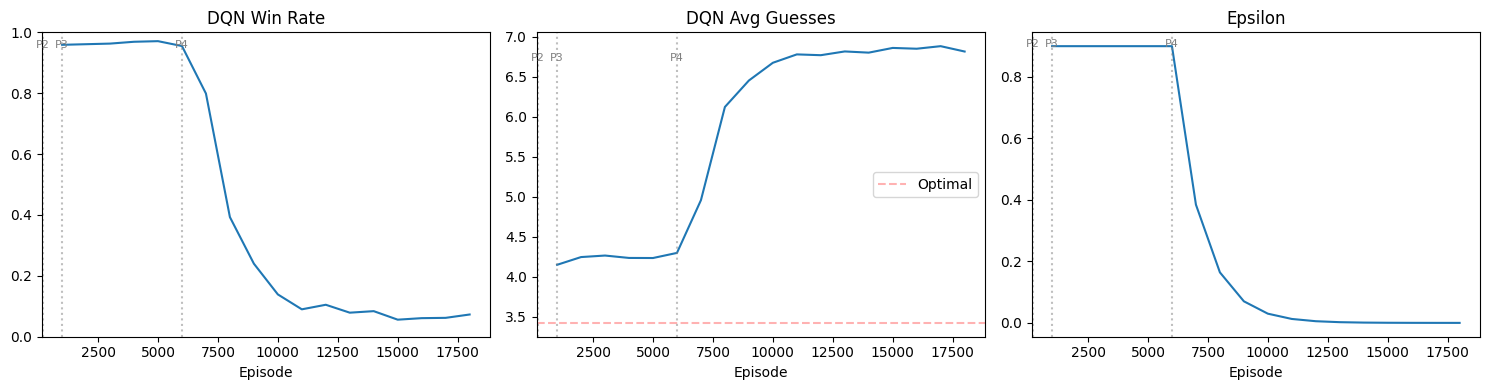

In [15]:
# DQN training curves with phase markers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Phase boundaries match train_dqn call
phase_eps = [200, 800, 5000, 12000]
boundaries = []
running = 0
for pe in phase_eps[:-1]:
    running += pe
    boundaries.append(running)

axes[0].plot(dqn_history["episode"], dqn_history["win_rate"])
axes[0].set_title("DQN Win Rate"); axes[0].set_xlabel("Episode"); axes[0].set_ylim(0, 1)
axes[0].axhline(y=1.0, color='r', linestyle='--', alpha=0.3)

axes[1].plot(dqn_history["episode"], dqn_history["avg_guesses"])
axes[1].set_title("DQN Avg Guesses"); axes[1].set_xlabel("Episode")
axes[1].axhline(y=3.421, color='r', linestyle='--', alpha=0.3, label='Optimal')
axes[1].legend()

axes[2].plot(dqn_history["episode"], dqn_history["epsilon"])
axes[2].set_title("Epsilon"); axes[2].set_xlabel("Episode")

# Add phase boundary lines to all plots
for ax in axes:
    for i, b in enumerate(boundaries):
        ax.axvline(x=b, color='gray', linestyle=':', alpha=0.5)
        ax.text(b, ax.get_ylim()[1]*0.95, f'P{i+2}', fontsize=8, ha='center', color='gray')

plt.tight_layout(); plt.savefig("dqn_training.png", dpi=150); plt.show()

In [16]:
dqn_solver = DQNSolver(model_path="models/dqn_model.pt")
demo_solver(dqn_solver)

Loaded DQN model from models/dqn_model.pt

Target: CRANE
  Turn 1: DUNES  ⬛ ⬛ 🟨 🟨 ⬛
  Turn 2: PLANK  ⬛ ⬛ 🟩 🟩 ⬛
  Turn 3: JEANS  ⬛ 🟨 🟩 🟩 ⬛
  Turn 4: TAPES  ⬛ 🟨 ⬛ 🟨 ⬛
  Turn 5: AWARE  ⬛ ⬛ 🟩 🟨 🟩
  Turn 6: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 6 guesses!

Target: SLINK
  Turn 1: DUNES  ⬛ ⬛ 🟨 ⬛ 🟨
  Turn 2: SCANT  🟩 ⬛ ⬛ 🟩 ⬛
  Turn 3: SHONE  🟩 ⬛ ⬛ 🟩 ⬛
  Turn 4: SHELL  🟩 ⬛ ⬛ 🟨 ⬛
  Turn 5: SKILL  🟩 🟨 🟩 🟨 ⬛
  Turn 6: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 6 guesses!

Target: NYMPH
  Turn 1: DUNES  ⬛ ⬛ 🟨 ⬛ ⬛
  Turn 2: RAYON  ⬛ ⬛ 🟨 ⬛ 🟨
  Turn 3: FULLY  ⬛ ⬛ ⬛ ⬛ 🟨
  Turn 4: HIRES  🟨 ⬛ ⬛ ⬛ ⬛
  Turn 5: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: FUZZY
  Turn 1: DUNES  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 2: CURLY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 3: CURVY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 4: CUBIC  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 5: TAWNY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 6: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 6 guesses!

Target: VIVID
  Turn 1: DUNES  🟨 ⬛ ⬛ ⬛ ⬛
  Turn 2: FRILL  ⬛ ⬛ 🟨 ⬛ ⬛
  Turn 3: PIGGY  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 4: SIGHT  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 5: RIGID  ⬛ 🟩 ⬛ 🟩 🟩
  Turn 6: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved

---
## Part 4: Tabular Q-Learning (Meta-Strategy Learning)

This approach implements a tabular Q-learning agent that learns **which strategy to use**
at each stage of the game, rather than directly selecting words.

### Key Insight

Instead of learning over a large action space of ~3,000 words, the agent learns over a
small set of **predefined strategies**. This reduces the action space to just 5 options,
making tabular reinforcement learning feasible and stable.

---

### State Representation

The game state is encoded as:

- **(# green letters, # yellow letters)** from the previous guess

This provides a coarse measure of progress (“how close the guess is to the target”).
The resulting state space is small (~20–30 reachable states), allowing the use of a
compact Q-table.

---

### Strategy Set (Actions)

The agent chooses from five strategies:

1. **Random**  
   Select a random word from the remaining candidate set  

2. **Curated List**  
   Select from a predefined set of high-information exploratory words derived from
   early-game frequency solver behavior  

3. **Frequency**  
   Score remaining candidates using letter frequency and select the highest-scoring word  

4. **Smart (Constraint-Based)**  
   Apply all known constraints (green positions, yellow letters, gray exclusions) to
   filter candidates, then select the best word using frequency scoring  

5. **Exclude-Only**  
   Use only gray-letter exclusions to filter candidates (ignoring yellow positional
   constraints), then select using frequency scoring  

---

### Training

The agent plays simulated games and updates a Q-table using standard Q-learning with
epsilon-greedy exploration.

- **Episodes:** ~10,000 games  
- **Exploration rate (ε):** 0.3  
- **Update rule:** standard tabular Q-learning  

Over time, the Q-values estimate the expected return of each strategy in each state,
leading to a learned policy.

---

### Reward Structure

The reward function provides intermediate feedback and terminal rewards:

- **Green letter:** +5  
- **Yellow letter:** +2  
- **Win:** +25  
- **Loss:** −15  

This reward design is an implementation choice in this project, intended to balance
information gain during intermediate steps with successful task completion.

---

### Output

The learned policy is a compact lookup table mapping states to strategies, for example:

- (0 green, 0 yellow) → **Curated List**  
- (2 green, 1 yellow) → **Smart**  

This results in a simple, interpretable decision policy that adapts behavior across
different stages of the game.

---

### Interpretation

This method does not attempt to solve Wordle directly. Instead, it learns a
**meta-policy over heuristics**, leveraging strong predefined strategies while using
reinforcement learning to determine when each is most effective.

This is broadly aligned with the idea explored in Anderson & Meyer (2022): that effective
Wordle play can be achieved by adapting strategy based on game state, rather than relying
on a single fixed policy.

In [19]:
print("Training Tabular Q-Learning...")
start_time = time.time()

q_table, q_history = train_tabular_q(
    num_episodes=10000,
    alpha=0.02,
    gamma=0.05,
    epsilon=0.3,
    curated_words=set3,
    log_interval=1000
)

print(f"\nTabular Q training: {(time.time()-start_time)/60:.1f} minutes")

os.makedirs("models", exist_ok=True)
with open("models/q_table.pkl", "wb") as f:
    pickle.dump(q_table, f)
print("Saved to models/q_table.pkl")

Training Tabular Q-Learning...
  Episode 1000: win_rate=0.961, avg_guesses=4.14
  Episode 2000: win_rate=0.959, avg_guesses=4.10
  Episode 3000: win_rate=0.963, avg_guesses=4.05
  Episode 4000: win_rate=0.969, avg_guesses=4.04
  Episode 5000: win_rate=0.978, avg_guesses=3.98
  Episode 6000: win_rate=0.974, avg_guesses=4.03
  Episode 7000: win_rate=0.975, avg_guesses=4.03
  Episode 8000: win_rate=0.971, avg_guesses=3.93
  Episode 9000: win_rate=0.986, avg_guesses=3.98
  Episode 10000: win_rate=0.978, avg_guesses=4.02

Tabular Q training: 4.2 minutes
Saved to models/q_table.pkl


In [20]:
# Show learned policy
print("Learned policy:")
print(f"{'State':>12}  {'Best Strategy':>15}")
print("-" * 35)
for state in sorted(q_table.keys()):
    best = int(np.argmax(q_table[state]))
    print(f"  ({state[0]}g, {state[1]}y)  {STRATEGY_NAMES[best]:>15}")

Learned policy:
       State    Best Strategy
-----------------------------------
  (0g, 0y)            smart
  (0g, 1y)            smart
  (0g, 2y)            smart
  (0g, 3y)        frequency
  (0g, 4y)           random
  (0g, 5y)          curated
  (1g, 0y)        frequency
  (1g, 1y)        frequency
  (1g, 2y)           random
  (1g, 3y)          curated
  (1g, 4y)          curated
  (2g, 0y)            smart
  (2g, 1y)        frequency
  (2g, 2y)          exclude
  (2g, 3y)           random
  (3g, 0y)        frequency
  (3g, 1y)           random
  (3g, 2y)        frequency
  (4g, 0y)            smart


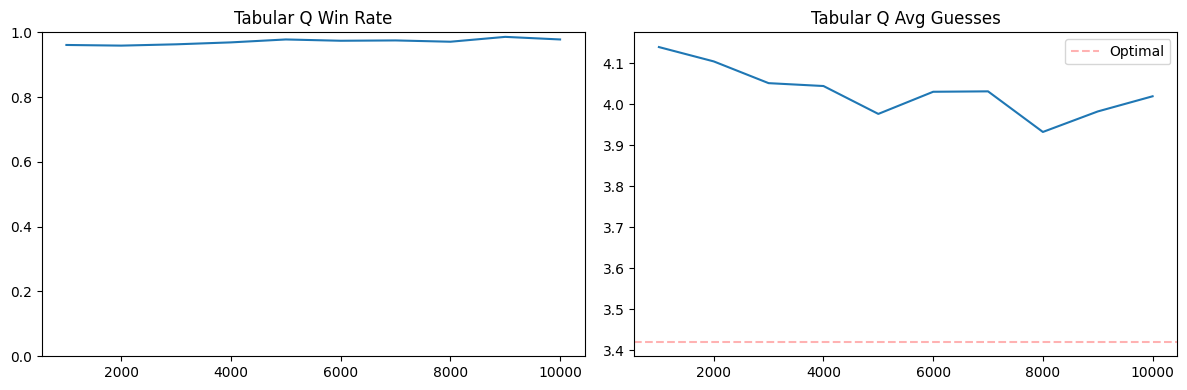

In [21]:
# Plot Q training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(q_history["episode"], q_history["win_rate"])
axes[0].set_title("Tabular Q Win Rate"); axes[0].set_ylim(0, 1)
axes[1].plot(q_history["episode"], q_history["avg_guesses"])
axes[1].set_title("Tabular Q Avg Guesses")
axes[1].axhline(y=3.421, color='r', linestyle='--', alpha=0.3, label='Optimal')
axes[1].legend()
plt.tight_layout(); plt.savefig("q_training.png", dpi=150); plt.show()

In [23]:
tq_solver = TabularQSolver(q_table_path="models/q_table.pkl", curated_words=set3)
demo_solver(tq_solver)

Loaded Q-table from models/q_table.pkl (19 states)

Target: CRANE
  Turn 1: AROSE  🟨 🟩 ⬛ ⬛ 🟩
  Turn 2: GRACE  ⬛ 🟩 🟩 🟨 🟩
  Turn 3: CRAZE  🟩 🟩 🟩 ⬛ 🟩
  Turn 4: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: SLINK
  Turn 1: AROSE  ⬛ ⬛ ⬛ 🟨 ⬛
  Turn 2: UNITS  ⬛ 🟨 🟩 ⬛ 🟨
  Turn 3: SLING  🟩 🟩 🟩 🟩 ⬛
  Turn 4: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: NYMPH
  Turn 1: AROSE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: UNITY  ⬛ 🟨 ⬛ ⬛ 🟨
  Turn 3: LYNCH  ⬛ 🟩 🟨 ⬛ 🟩
  Turn 4: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: FUZZY
  Turn 1: AROSE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: UNITY  🟨 ⬛ ⬛ ⬛ 🟩
  Turn 3: DUMPY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 4: BULKY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: AROSE  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: UNITY  ⬛ ⬛ 🟨 ⬛ ⬛
  Turn 3: CIVIL  ⬛ 🟩 🟩 🟩 ⬛
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


---
## Part 5: Rollout (Bhambri et al., 2022)

This solver implements a **rollout / one-step lookahead** method inspired by Bhambri,
Bhattacharjee, and Bertsekas (2022), who frame Wordle as a sequential decision problem and
apply approximate dynamic programming via policy improvement.

The core idea is to improve a base heuristic by evaluating the **expected downstream
cost** of each candidate guess using one-step lookahead.

---

### Core Idea

At any turn, the game state is the set of remaining candidate words, denoted by $S$.

For each candidate guess $g$, the solver considers all possible hidden words
$w \in S$. Each hidden word produces a feedback pattern, which determines a new reduced
candidate set $S'$.

Instead of selecting a guess based only on immediate statistics, rollout evaluates:

> If I play guess $g$ now, and then follow my base policy, how many total guesses will I
> need on average?

Formally, the rollout value of a guess $g$ is:

$$
Q(g) = \frac{1}{|S|} \sum_{w \in S} \text{cost}(g, w)
$$

and the selected guess is:

$$
g^* = \arg\min_g Q(g)
$$

This is a **one-step policy improvement**: it uses the base heuristic to approximate future
costs, while explicitly optimizing the current decision.

---

### Why this is Dynamic Programming in Practice

This method naturally forms a **dynamic programming structure**:

- The subproblem is: “given a candidate set $S$, what is the best next guess?”
- Many different game paths lead to the same $S$
- Once solved, the result for $S$ can be reused

With memoization, rollout becomes:

- **Without caching:** repeated forward simulation  
- **With caching:** a DP-style lookup over visited states  

In practice, this behaves like a **memoized approximate dynamic program** over reachable
candidate sets.

---

### Candidate Selection (Top-$N$ Restriction)

Evaluating rollout over all possible guesses is expensive. Following Bhambri et al., the
solver restricts evaluation to a small set of promising candidates:

1. Score all words using a fast heuristic  
2. Select the top $N$ candidates (e.g., $N = 10$)  
3. Run full rollout evaluation only on those candidates  

This preserves most of the benefit of rollout while keeping computation tractable.

---

### Base Policy

Rollout improves a **base policy**, which is used to simulate future play.

In this implementation, the base policy is the frequency heuristic, with an additional
practical refinement:

- **frequency scoring** when the remaining set is large  
- **minimax-style partition scoring** when the remaining set is small  

This is a project-specific engineering choice inspired by the rollout framework, but not a
direct reproduction of the exact setup in Bhambri et al.

---

### Detailed Mechanics in This Implementation

At each turn, the solver proceeds as follows:

1. Let $S$ be the current set of remaining candidate words.  
2. Generate a short list of promising guesses using a fast scoring rule.  
3. For each candidate guess $g$ in that short list:
   - simulate feedback against **every** hidden word $w \in S$  
   - apply the resulting feedback to produce the next candidate set $S'$  
   - if $S'$ is already cached, reuse the stored best action / cost  
   - otherwise, continue by following the base policy from $S'$  
   - record the total number of guesses needed to solve each case  
4. Average those totals across all $w \in S$  
5. Choose the guess with minimum average total cost  

---

### Relationship to Minimax

- **Minimax** optimizes the **worst-case** next partition size  
- **Rollout** optimizes the **expected** total solving cost  

Minimax is conservative and guards against the worst outcome. Rollout instead optimizes
average performance, often achieving fewer guesses overall.

---

### Cache / Memoization

Results are memoized to disk (e.g., `models/rollout_cache.pkl`), mapping each visited
candidate set to its optimal next action.

On the 2,983-word benchmark, this process resulted in **431 unique visited states**.
This reflects the number of distinct candidate sets encountered during rollout evaluation
in this implementation.

Once cached, evaluation becomes effectively instantaneous.

---

### Interpretation

This method is best understood as a **memoized approximate dynamic programming approach**:

- It is not exact dynamic programming over the full game tree  
- It is a DP-style policy improvement method with overlapping subproblems  
- In practice, it behaves like a dynamic program over reachable candidate sets  

This combination of structured lookahead and memoization is what allows rollout to achieve
near-optimal performance in Wordle-like environments.

In [24]:
rollout_solver = RolloutSolver(top_k=10)
demo_solver(rollout_solver)

Loaded rollout cache: 431 states from /content/wordle-ML-project/models/rollout_cache.pkl

Target: CRANE
  Turn 1: TIRES  ⬛ ⬛ 🟨 🟨 ⬛
  Turn 2: BRACE  ⬛ 🟩 🟩 🟨 🟩
  Turn 3: ANVIL  🟨 🟨 ⬛ ⬛ ⬛
  Turn 4: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!

Target: SLINK
  Turn 1: TIRES  ⬛ 🟨 ⬛ ⬛ 🟨
  Turn 2: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 2 guesses!

Target: NYMPH
  Turn 1: TIRES  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: BALMY  ⬛ ⬛ ⬛ 🟨 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: TIRES  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: BALMY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: PRONG  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 4: DUCHY  ⬛ 🟩 ⬛ ⬛ 🟩
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: TIRES  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 2: DIMLY  🟨 🟩 ⬛ ⬛ ⬛
  Turn 3: KIDDO  ⬛ 🟩 🟨 ⬛ ⬛
  Turn 4: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 4 guesses!


---
## Part 6: DQN v2 — Teacher-Guided (Reward-Shaped)

DQN v1 showed that a pure deep RL approach struggles in this environment. As exploration
decreases, the model’s own decisions begin to dominate training data. If those decisions
are poor, the replay buffer fills with low-quality trajectories, which can degrade
learning over time (a form of policy-induced distribution shift).

Empirically, the learned policy in v1 underperformed even simple baselines, suggesting
that the model did not develop a strong internal representation of what makes a guess
informative.

---

### Diagnosis

The primary issue is **exploration quality**.

- Curated exploration provides reasonable early-game guesses  
- However, it does not provide a direct learning signal for *why* those guesses are good  
- Once the model must act independently, it lacks a reliable policy  

This is a known challenge in RL: exploration must not only cover the space, but also
produce **useful training signals**.

---

### Approach: Teacher-Guided Learning

DQN v2 introduces a **teacher-guided training strategy**, using the rollout solver as a
high-quality policy to guide learning.

Rather than relying on random or curated exploration, the agent observes and partially
imitates a strong policy during training. This results in a hybrid approach combining:

- reinforcement learning (value estimation)  
- imitation learning (learning from demonstrations)  

---

### Key Modifications from v1

#### 1. Teacher-Guided Exploration

When exploring (with probability $\epsilon$), the agent follows the rollout solver’s
recommended action instead of selecting a random or curated guess.

This ensures that:

- exploration trajectories are high-quality  
- the replay buffer contains useful state-action examples  
- training is anchored to a strong reference policy  

---

#### 2. Reward Shaping Toward Teacher Policy

An additional reward bonus is given when the model selects the same action as the teacher:

- **Match teacher action:** +20 bonus  

This supplements the base reward signal and creates a stronger gradient toward
teacher-aligned behavior, especially in states where immediate feedback is ambiguous.

---

#### 3. Exploration Schedule

- $\epsilon$ decays from **0.9 → 0.4** over training  
- Exploration never drops below 40%  

Maintaining a nonzero level of teacher guidance prevents the model from drifting too far
from useful behavior, addressing the instability observed in v1.

---

#### 4. Expanded Rollout Cache

The rollout solver is memoized. During training:

- initial cache contains states encountered during precomputation  
- additional states are added as the DQN explores off-policy trajectories  

This allows the teacher to provide guidance even in previously unseen states.

---

### Architecture

The model architecture is unchanged from DQN v1:

- **Input:** 417-dimensional state vector  
- **Hidden layers:** 512 → 512 fully connected layers  
- **Output:** 130-dimensional factorized representation  
- **Action scoring:** dot product with word encodings  

All improvements come from changes to the training process rather than model structure.

---

### Training Setup

- **Episodes:** ~10,000  
- **Replay buffer:** 100,000 transitions  
- **Target network:** periodic updates  
- **Compute cost:** significantly higher than v1 due to rollout evaluation at each step  

---

### Interpretation

This method should be viewed as a **hybrid RL + imitation learning approach**:

- RL provides a value-learning framework  
- The rollout solver provides high-quality supervision  
- Reward shaping aligns the learned policy with the teacher  

The goal is not to exceed the rollout solver, but to **approximate its policy using a
neural network**.

---

### Key Insight

Even with strong teacher guidance, performance is constrained by:

- the factorized action representation  
- the difficulty of approximating structured logical reasoning with a neural network  

This highlights an important result of the project:

> In structured, fully observable environments like Wordle, learning from demonstration
> can improve stability, but explicit search-based methods remain more reliable than
> learned value-function approximations.

In [25]:
def train_dqn_v2(num_episodes=10000, batch_size=64, gamma=0.95,
                 epsilon_start=0.9, epsilon_end=0.4, epsilon_decay=0.9999,
                 lr=0.001, target_update=200, log_interval=500,
                 rollout_solver=None):
    """DQN v2: imitation learning from rollout solver."""

    word_to_idx = {w: i for i, w in enumerate(WORDS)}
    policy_net = DQNNetwork().to(device)
    target_net = DQNNetwork().to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=100000)
    word_enc = WORD_ENCODINGS.to(device)

    history = {"episode": [], "win_rate": [], "avg_guesses": [], "epsilon": []}
    recent_wins = []
    recent_guesses = []
    epsilon = epsilon_start
    cache_before = len(rollout_solver.cache) if rollout_solver else 0

    for episode in range(num_episodes):
        target = random.choice(WORDS)
        game = WordleGame(target=target, word_list=WORDS)
        guesses, feedbacks_list = [], []
        remaining = list(WORDS)

        if rollout_solver:
            rollout_solver.reset()

        while not game.is_over():
            state = encode_state(guesses, feedbacks_list, game.turn)
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

            # Always get the optimal move from rollout
            optimal_guess = None
            if rollout_solver and len(remaining) > 1:
                rollout_solver.remaining = list(remaining)
                rollout_solver.guesses = list(guesses)
                rollout_solver.feedbacks = list(feedbacks_list)
                optimal_guess = rollout_solver.get_guess()

            if random.random() < epsilon:
                # Exploration = follow the teacher (rollout)
                if optimal_guess:
                    guess = optimal_guess
                else:
                    guess = remaining[0]
                action_idx = word_to_idx[guess]
            else:
                # Exploitation = model picks
                with torch.no_grad():
                    output = policy_net(state_t)
                    scores = torch.matmul(output, word_enc.T).squeeze(0)
                    action_idx = scores.argmax().item()

            guess = WORDS[action_idx]
            feedback = game.make_guess(guess)
            guesses.append(guess)
            feedbacks_list.append(feedback)
            remaining = filter_words(remaining, guess, feedback)

            solved = game.is_solved()
            failed = game.turn >= 6 and not solved

            # Normal reward
            reward = compute_reward(feedback, solved, failed, game.turn, 1.0)

            # Bonus for matching rollout
            if optimal_guess and guess == optimal_guess:
                reward += 20.0

            next_state = encode_state(guesses, feedbacks_list, game.turn)
            done = solved or failed

            replay_buffer.push(state, action_idx, reward, next_state, done)

            if len(replay_buffer) >= batch_size:
                s_b, a_b, r_b, ns_b, d_b = replay_buffer.sample(batch_size)
                s_b, a_b, r_b = s_b.to(device), a_b.to(device), r_b.to(device)
                ns_b, d_b = ns_b.to(device), d_b.to(device)

                out = policy_net(s_b)
                q_vals = torch.matmul(out, word_enc.T).gather(1, a_b.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    next_q = torch.matmul(target_net(ns_b), word_enc.T).max(dim=1)[0]
                    target_q = r_b + gamma * next_q * (1 - d_b)

                loss = F.mse_loss(q_vals, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            if done:
                break

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        if episode % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

        recent_wins.append(1 if game.is_solved() else 0)
        recent_guesses.append(game.turn if game.is_solved() else 7)
        if len(recent_wins) > 1000:
            recent_wins.pop(0)
            recent_guesses.pop(0)

        if (episode + 1) % log_interval == 0:
            wr = sum(recent_wins) / len(recent_wins)
            ag = sum(recent_guesses) / len(recent_guesses)
            cache_size = len(rollout_solver.cache) if rollout_solver else 0
            history["episode"].append(episode + 1)
            history["win_rate"].append(wr)
            history["avg_guesses"].append(ag)
            history["epsilon"].append(epsilon)
            print(f"  Ep {episode+1}: win={wr:.3f}, avg={ag:.2f}, eps={epsilon:.3f}, cache={cache_size}")

    if rollout_solver:
        cache_after = len(rollout_solver.cache)
        print(f"\nCache grew: {cache_before} → {cache_after} states (+{cache_after - cache_before})")
        rollout_solver.save_cache()

    return policy_net, history

In [26]:
# Load rollout solver with existing cache
rollout_solver = RolloutSolver(top_k=10)

print(f"Starting cache: {len(rollout_solver.cache)} states")
print("Training DQN v2 (reward shaped with live rollout)...")
start_time = time.time()

dqn_v2_model, dqn_v2_history = train_dqn_v2(
    num_episodes=10000,
    rollout_solver=rollout_solver,
    log_interval=500
)

print(f"\nDQN v2 training: {(time.time()-start_time)/60:.1f} minutes")
torch.save(dqn_v2_model.state_dict(), "models/dqn_v2_model.pt")

Loaded rollout cache: 431 states from /content/wordle-ML-project/models/rollout_cache.pkl
Starting cache: 431 states
Training DQN v2 (reward shaped with live rollout)...
  Ep 500: win=1.000, avg=3.81, eps=0.856, cache=563
  Ep 1000: win=0.992, avg=3.86, eps=0.814, cache=700
  Ep 1500: win=0.978, avg=3.96, eps=0.775, cache=898
  Ep 2000: win=0.964, avg=4.12, eps=0.737, cache=1102
  Ep 2500: win=0.953, avg=4.26, eps=0.701, cache=1382
  Ep 3000: win=0.943, avg=4.30, eps=0.667, cache=1608
  Ep 3500: win=0.927, avg=4.32, eps=0.634, cache=1834
  Ep 4000: win=0.912, avg=4.38, eps=0.603, cache=2069
  Ep 4500: win=0.902, avg=4.50, eps=0.574, cache=2314
  Ep 5000: win=0.877, avg=4.62, eps=0.546, cache=2572
  Ep 5500: win=0.847, avg=4.68, eps=0.519, cache=2831
  Ep 6000: win=0.843, avg=4.71, eps=0.494, cache=3086
  Ep 6500: win=0.849, avg=4.74, eps=0.470, cache=3307
  Ep 7000: win=0.843, avg=4.74, eps=0.447, cache=3510
  Ep 7500: win=0.815, avg=4.82, eps=0.425, cache=3719
  Ep 8000: win=0.771, av

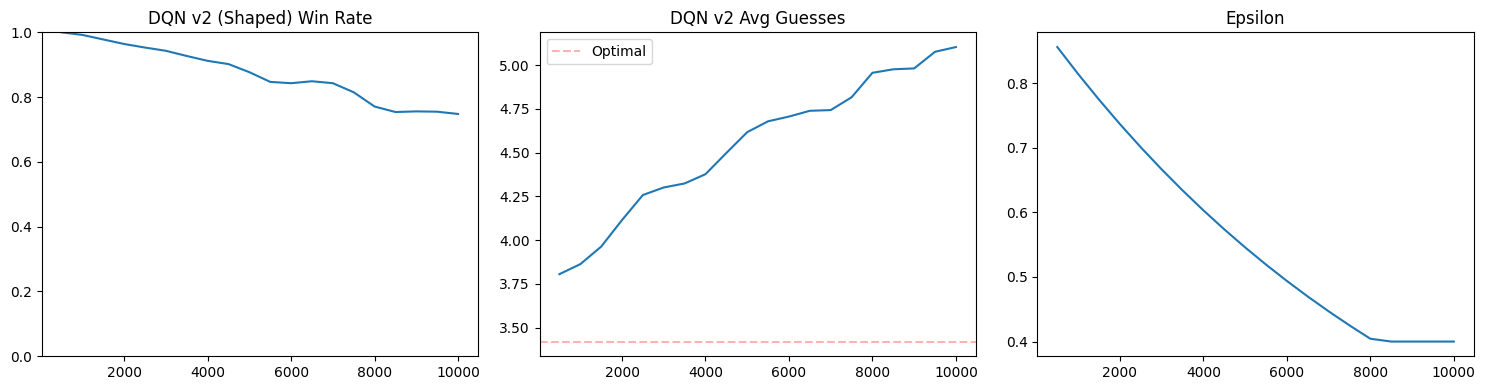

In [27]:
# DQN v2 training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(dqn_v2_history["episode"], dqn_v2_history["win_rate"])
axes[0].set_title("DQN v2 (Shaped) Win Rate"); axes[0].set_ylim(0, 1)
axes[0].axhline(y=1.0, color='r', linestyle='--', alpha=0.3)
axes[1].plot(dqn_v2_history["episode"], dqn_v2_history["avg_guesses"])
axes[1].set_title("DQN v2 Avg Guesses")
axes[1].axhline(y=3.421, color='r', linestyle='--', alpha=0.3, label='Optimal')
axes[1].legend()
axes[2].plot(dqn_v2_history["episode"], dqn_v2_history["epsilon"])
axes[2].set_title("Epsilon")
plt.tight_layout(); plt.savefig("dqn_v2_training.png", dpi=150); plt.show()

In [28]:
dqn_v2_solver = DQNSolver(model_path="models/dqn_v2_model.pt")
demo_solver(dqn_v2_solver)

Loaded DQN model from models/dqn_v2_model.pt

Target: CRANE
  Turn 1: TIRES  ⬛ ⬛ 🟨 🟨 ⬛
  Turn 2: BRACE  ⬛ 🟩 🟩 🟨 🟩
  Turn 3: ABACK  ⬛ ⬛ 🟩 🟨 ⬛
  Turn 4: DRUNK  ⬛ 🟩 ⬛ 🟩 ⬛
  Turn 5: CRANE  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: SLINK
  Turn 1: TIRES  ⬛ 🟨 ⬛ ⬛ 🟨
  Turn 2: SLINK  🟩 🟩 🟩 🟩 🟩
  Solved in 2 guesses!

Target: NYMPH
  Turn 1: TIRES  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: BALMY  ⬛ ⬛ ⬛ 🟨 🟨
  Turn 3: NYMPH  🟩 🟩 🟩 🟩 🟩
  Solved in 3 guesses!

Target: FUZZY
  Turn 1: TIRES  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 2: BALMY  ⬛ ⬛ ⬛ ⬛ 🟩
  Turn 3: PRONG  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 4: PUFFY  ⬛ 🟩 🟨 ⬛ 🟩
  Turn 5: FUZZY  🟩 🟩 🟩 🟩 🟩
  Solved in 5 guesses!

Target: VIVID
  Turn 1: TIRES  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 2: WIMPY  ⬛ 🟩 ⬛ ⬛ ⬛
  Turn 3: LIVEN  ⬛ 🟩 🟩 ⬛ ⬛
  Turn 4: TOOTH  ⬛ ⬛ ⬛ ⬛ ⬛
  Turn 5: DIGIT  🟨 🟩 ⬛ 🟩 ⬛
  Turn 6: VIVID  🟩 🟩 🟩 🟩 🟩
  Solved in 6 guesses!


---
## Part 7: Evaluation — All Six Solvers

Run each solver against every word. Measure win rate, average guesses, distribution.

In [29]:
def evaluate_solver(solver, words, name="Solver", max_words=None):
    test_words = words[:max_words] if max_words else words
    results = []
    for target in tqdm(test_words, desc=name):
        game = WordleGame(target=target, word_list=words)
        solver.reset()
        while not game.is_over():
            guess = solver.get_guess()
            feedback = game.make_guess(guess)
            solver.update(guess, feedback)
            if game.is_solved(): break
        guesses_used = game.turn if game.is_solved() else 7
        results.append({"word": target, "guesses": guesses_used, "solved": game.is_solved()})

    guess_counts = [r["guesses"] for r in results]
    solved_counts = [r["guesses"] for r in results if r["solved"]]
    return {
        "name": name, "total_words": len(test_words),
        "solved": sum(1 for r in results if r["solved"]),
        "win_rate": sum(1 for r in results if r["solved"]) / len(test_words),
        "avg_guesses": np.mean(solved_counts) if solved_counts else float('inf'),
        "avg_guesses_all": np.mean(guess_counts),
        "max_guesses": max(guess_counts), "min_guesses": min(guess_counts),
        "distribution": guess_counts, "results": results
    }

def print_summary(s):
    print(f"\n{'='*50}")
    print(f"  {s['name']}")
    print(f"{'='*50}")
    print(f"  Words tested:    {s['total_words']}")
    print(f"  Solved:          {s['solved']} ({s['win_rate']*100:.1f}%)")
    print(f"  Avg guesses:     {s['avg_guesses']:.3f} (solved only)")
    print(f"  Avg guesses:     {s['avg_guesses_all']:.3f} (all, 7=fail)")
    print(f"  Min guesses:     {s['min_guesses']}")
    print(f"  Max guesses:     {s['max_guesses']}")
    dist = Counter(s['distribution'])
    print(f"\n  Distribution:")
    for k in sorted(dist.keys()):
        label = f"{k}" if k <= 6 else "7+ (fail)"
        bar = "█" * (dist[k] * 40 // s['total_words'])
        print(f"    {label:>10}: {dist[k]:>5} ({dist[k]/s['total_words']*100:5.1f}%) {bar}")

In [31]:
MAX_WORDS = None  # Set to 50 for quick test, None for full eval
all_results = {}

In [32]:
# Solver 1: Frequency Heuristic
freq_solver = FrequencySolver()
all_results["frequency"] = evaluate_solver(freq_solver, WORDS, "Frequency Heuristic", MAX_WORDS)
print_summary(all_results["frequency"])

Frequency Heuristic: 100%|██████████| 2983/2983 [03:00<00:00, 16.56it/s]


  Frequency Heuristic
  Words tested:    2983
  Solved:          2978 (99.8%)
  Avg guesses:     3.707 (solved only)
  Avg guesses:     3.712 (all, 7=fail)
  Min guesses:     1
  Max guesses:     7

  Distribution:
             1:     1 (  0.0%) 
             2:   125 (  4.2%) █
             3:  1050 ( 35.2%) ██████████████
             4:  1403 ( 47.0%) ██████████████████
             5:   369 ( 12.4%) ████
             6:    30 (  1.0%) 
     7+ (fail):     5 (  0.2%) 


In [33]:
# Solver 2: Information Gain
ig_solver = InfoGainSolver()
all_results["infogain"] = evaluate_solver(ig_solver, WORDS, "Information Gain", MAX_WORDS)
print_summary(all_results["infogain"])

Computing best opening guess (one-time cost)...
  Best opener: RAISE (21.2s)


Information Gain: 100%|██████████| 2983/2983 [27:21<00:00,  1.82it/s]


  Information Gain
  Words tested:    2983
  Solved:          2983 (100.0%)
  Avg guesses:     3.728 (solved only)
  Avg guesses:     3.728 (all, 7=fail)
  Min guesses:     1
  Max guesses:     6

  Distribution:
             1:     1 (  0.0%) 
             2:    57 (  1.9%) 
             3:   961 ( 32.2%) ████████████
             4:  1699 ( 57.0%) ██████████████████████
             5:   262 (  8.8%) ███
             6:     3 (  0.1%) 


In [34]:
# Solver 3: DQN
dqn_solver = DQNSolver(model_path="models/dqn_model.pt")
all_results["dqn"] = evaluate_solver(dqn_solver, WORDS, "DQN", MAX_WORDS)
print_summary(all_results["dqn"])

Loaded DQN model from models/dqn_model.pt


DQN: 100%|██████████| 2983/2983 [00:27<00:00, 108.65it/s]


  DQN
  Words tested:    2983
  Solved:          2045 (68.6%)
  Avg guesses:     4.343 (solved only)
  Avg guesses:     5.179 (all, 7=fail)
  Min guesses:     1
  Max guesses:     7

  Distribution:
             1:     1 (  0.0%) 
             2:    46 (  1.5%) 
             3:   413 ( 13.8%) █████
             4:   690 ( 23.1%) █████████
             5:   580 ( 19.4%) ███████
             6:   315 ( 10.6%) ████
     7+ (fail):   938 ( 31.4%) ████████████


In [35]:
# Solver 4: Tabular Q
tq_solver = TabularQSolver(q_table_path="models/q_table.pkl", curated_words=set3)
all_results["tabular_q"] = evaluate_solver(tq_solver, WORDS, "Tabular Q-Learning", MAX_WORDS)
print_summary(all_results["tabular_q"])

Loaded Q-table from models/q_table.pkl (19 states)


Tabular Q-Learning: 100%|██████████| 2983/2983 [00:47<00:00, 62.64it/s]


  Tabular Q-Learning
  Words tested:    2983
  Solved:          2939 (98.5%)
  Avg guesses:     3.827 (solved only)
  Avg guesses:     3.874 (all, 7=fail)
  Min guesses:     1
  Max guesses:     7

  Distribution:
             1:     1 (  0.0%) 
             2:   130 (  4.4%) █
             3:   982 ( 32.9%) █████████████
             4:  1225 ( 41.1%) ████████████████
             5:   466 ( 15.6%) ██████
             6:   135 (  4.5%) █
     7+ (fail):    44 (  1.5%) 


In [36]:
# Solver 5: Rollout
rollout_solver = RolloutSolver(top_k=10)
all_results["rollout"] = evaluate_solver(rollout_solver, WORDS, "Rollout", MAX_WORDS)
print_summary(all_results["rollout"])

# Save cache for future runs
rollout_solver.save_cache()
print(rollout_solver.cache_stats())

Loaded rollout cache: 4627 states from /content/wordle-ML-project/models/rollout_cache.pkl


Rollout: 100%|██████████| 2983/2983 [00:20<00:00, 147.53it/s]


  Rollout
  Words tested:    2983
  Solved:          2983 (100.0%)
  Avg guesses:     3.568 (solved only)
  Avg guesses:     3.568 (all, 7=fail)
  Min guesses:     1
  Max guesses:     6

  Distribution:
             1:     1 (  0.0%) 
             2:   104 (  3.5%) █
             3:  1251 ( 41.9%) ████████████████
             4:  1460 ( 48.9%) ███████████████████
             5:   160 (  5.4%) ██
             6:     7 (  0.2%) 
Saved rollout cache: 4627 states to /content/wordle-ML-project/models/rollout_cache.pkl
Cache: 4627 states, 7572 hits / 0 misses (100.0% hit rate)


In [37]:
# Solver 6: DQN v2 (Reward Shaped)
dqn_v2_solver = DQNSolver(model_path="models/dqn_v2_model.pt")
all_results["dqn_v2"] = evaluate_solver(dqn_v2_solver, WORDS, "DQN v2 (Shaped)", MAX_WORDS)
print_summary(all_results["dqn_v2"])

Loaded DQN model from models/dqn_v2_model.pt


DQN v2 (Shaped): 100%|██████████| 2983/2983 [00:26<00:00, 111.05it/s]


  DQN v2 (Shaped)
  Words tested:    2983
  Solved:          2348 (78.7%)
  Avg guesses:     4.059 (solved only)
  Avg guesses:     4.685 (all, 7=fail)
  Min guesses:     1
  Max guesses:     7

  Distribution:
             1:     1 (  0.0%) 
             2:    68 (  2.3%) 
             3:   668 ( 22.4%) ████████
             4:   923 ( 30.9%) ████████████
             5:   430 ( 14.4%) █████
             6:   258 (  8.6%) ███
     7+ (fail):   635 ( 21.3%) ████████


---
## Part 8: Comparison & Visualization

In [38]:
solver_keys = ["frequency", "infogain", "dqn", "tabular_q", "rollout", "dqn_v2"]

print(f"\n{'Solver':<25} {'Win Rate':>10} {'Avg Guesses':>12} {'Max':>5}")
print("-" * 55)
for key in solver_keys:
    r = all_results[key]
    print(f"{r['name']:<25} {r['win_rate']*100:>9.1f}% {r['avg_guesses']:>12.3f} {r['max_guesses']:>5}")
print("-" * 55)
print(f"{'Optimal (Bertsimas)':<25} {'100.0%':>10} {'3.421':>12} {'5':>5}")


Solver                      Win Rate  Avg Guesses   Max
-------------------------------------------------------
Frequency Heuristic            99.8%        3.707     7
Information Gain              100.0%        3.728     6
DQN                            68.6%        4.343     7
Tabular Q-Learning             98.5%        3.827     7
Rollout                       100.0%        3.568     6
DQN v2 (Shaped)                78.7%        4.059     7
-------------------------------------------------------
Optimal (Bertsimas)           100.0%        3.421     5


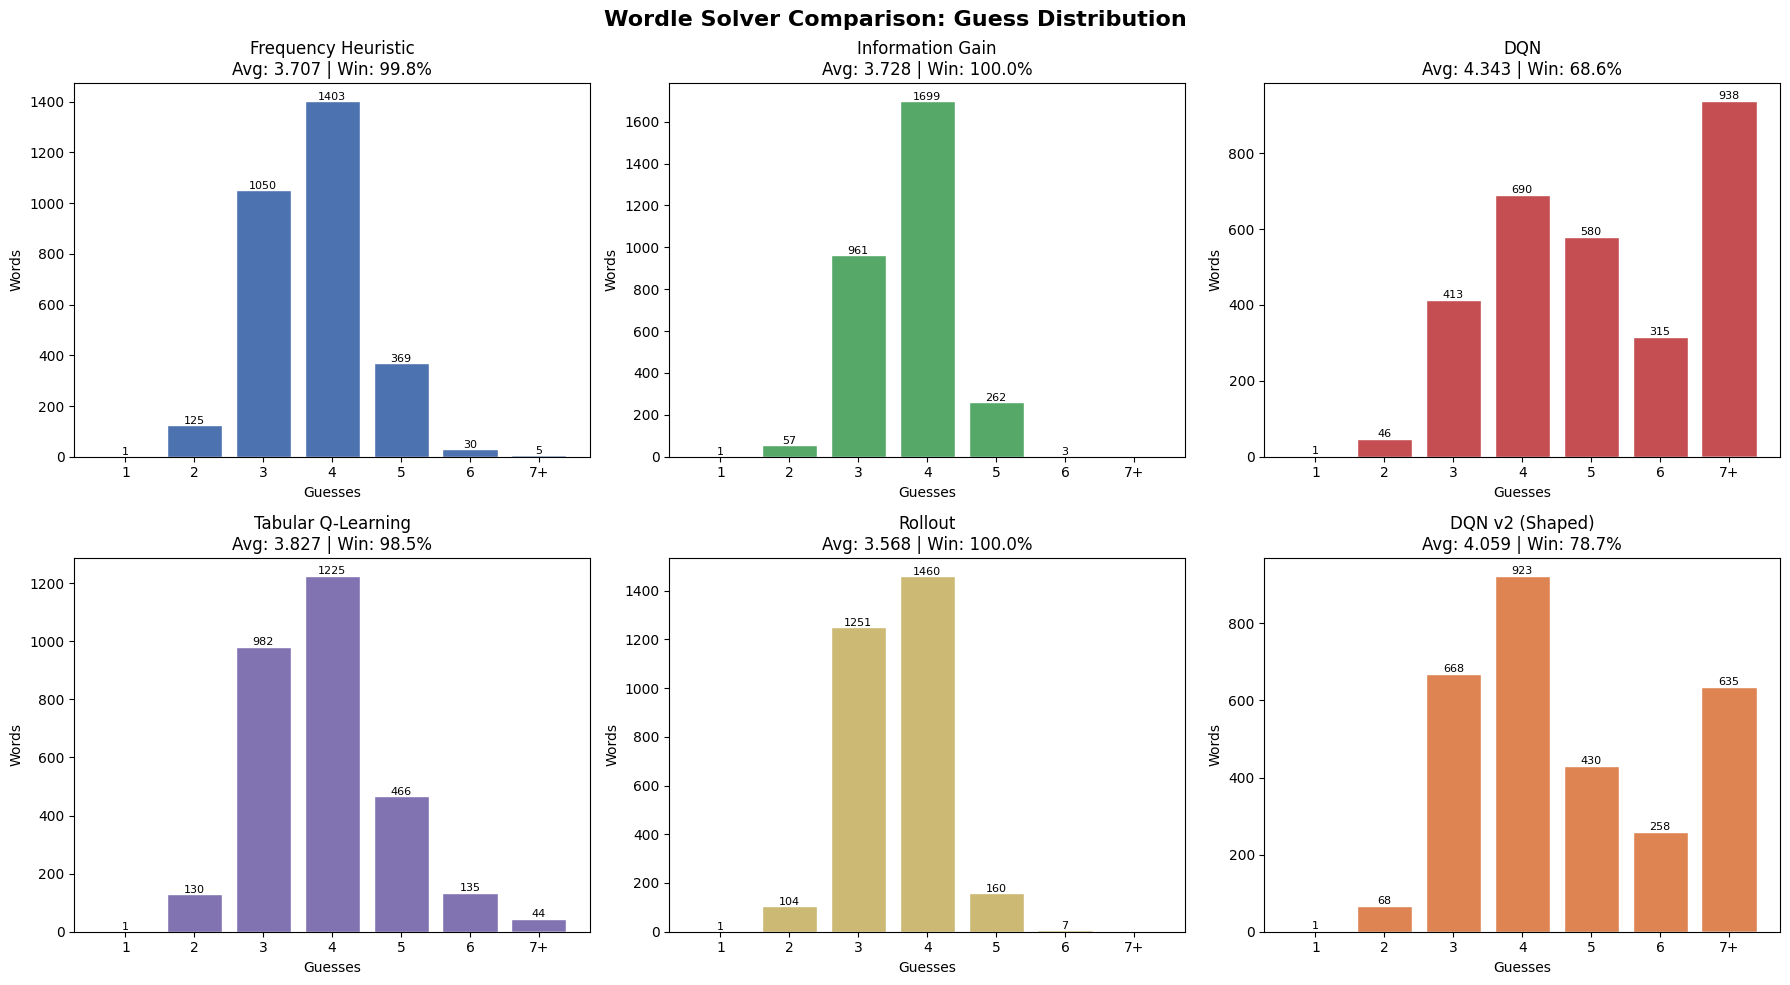

In [39]:
# Individual histograms
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Wordle Solver Comparison: Guess Distribution", fontsize=16, fontweight='bold')
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#DD8452"]

for ax, key, color in zip(axes.flat[:6], solver_keys, colors):
    r = all_results[key]
    bins = range(1, 9)
    counts = [r["distribution"].count(i) for i in bins]
    labels = [str(i) if i <= 6 else "7+" for i in bins]
    ax.bar(labels, counts, color=color, edgecolor='white')
    for bar, c in zip(ax.patches, counts):
        if c > 0: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(c), ha='center', fontsize=8)
    ax.set_title(f"{r['name']}\nAvg: {r['avg_guesses']:.3f} | Win: {r['win_rate']*100:.1f}%")
    ax.set_xlabel("Guesses"); ax.set_ylabel("Words")

plt.tight_layout(); plt.savefig("solver_comparison.png", dpi=150); plt.show()

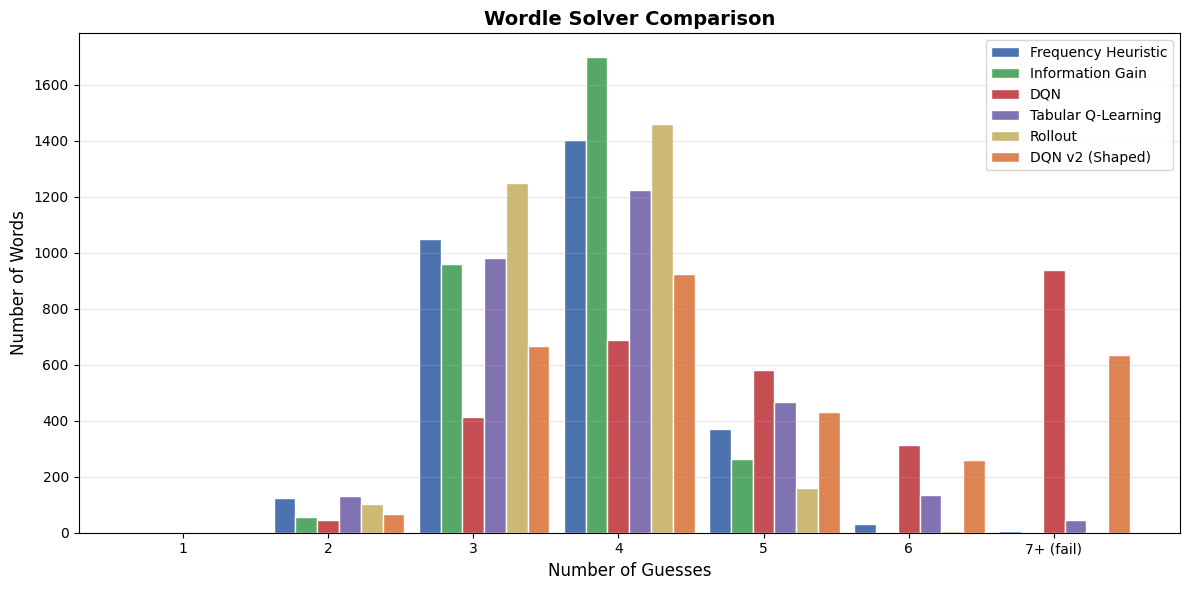

In [40]:
# Overlaid comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(1, 8)
width = 0.15
for i, (key, color) in enumerate(zip(solver_keys, colors)):
    r = all_results[key]
    counts = [r["distribution"].count(g) for g in range(1, 8)]
    offset = (i - 2) * width
    ax.bar(x + offset, counts, width, label=r["name"], color=color, edgecolor='white')

ax.set_xlabel("Number of Guesses", fontsize=12)
ax.set_ylabel("Number of Words", fontsize=12)
ax.set_title("Wordle Solver Comparison", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(i) if i <= 6 else "7+ (fail)" for i in range(1, 8)])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig("solver_overlay.png", dpi=150); plt.show()

In [41]:
# Hardest words per solver
print("\nHardest words (most guesses) per solver:")
print("=" * 60)
for key in solver_keys:
    r = all_results[key]
    worst = sorted(r["results"], key=lambda x: -x["guesses"])
    print(f"\n{r['name']}:")
    for item in worst[:5]:
        s = "FAIL" if not item["solved"] else f"{item['guesses']} guesses"
        print(f"  {item['word'].upper():>8} — {s}")


Hardest words (most guesses) per solver:

Frequency Heuristic:
     ROGER — FAIL
     ROVER — FAIL
     VAUNT — FAIL
     OOZED — FAIL
     OOZES — FAIL

Information Gain:
     MOVER — 6 guesses
     GOFER — 6 guesses
     JOKES — 6 guesses
     AWAKE — 5 guesses
     BADLY — 5 guesses

DQN:
     ABATE — FAIL
     ABBOT — FAIL
     ADOBE — FAIL
     ADORE — FAIL
     AFOOT — FAIL

Tabular Q-Learning:
     BROOM — FAIL
     CATCH — FAIL
     DADDY — FAIL
     GRAZE — FAIL
     HATCH — FAIL

Rollout:
     JOKER — 6 guesses
     NEVER — 6 guesses
     QUEER — 6 guesses
     FAXES — 6 guesses
     GAZED — 6 guesses

DQN v2 (Shaped):
     ABBEY — FAIL
     ABHOR — FAIL
     ABODE — FAIL
     ABOVE — FAIL
     ADAGE — FAIL


---
## Summary

| Solver | Type | Win Rate | Avg Guesses | Speed (it/s) | Reference |
|--------|------|----------|-------------|--------------|-----------|
| **Optimal** | **Exact DP** | **100.0%** | **3.421** | **—** | **Bertsimas & Paskov (2024)** |
| Rollout (POMDP) | DP/Lookahead | 100.0% | 3.568 | 147.53 | Bhambri et al. (2022) |
| Information Gain | Heuristic | 100.0% | 3.728 | 1.82 | Liu (2022) |
| Frequency Heuristic | Heuristic | 99.8% | 3.707 | 16.56 | Baseline (original, 2021) |
| Tabular Q-Learning | RL | 98.5% | 3.827 | 62.64 | Anderson & Meyer (2022) |
| DQN v2 (Reward Shaped) | Deep RL | 78.7% | 4.059 | 111.05 | Ho (2022) + rollout teacher |
| DQN v1 (Pure) | Deep RL | 68.6% | 4.343 | 108.65 | Ho (2022) |

---
## Final Summary and Discussion

This project compared multiple solver paradigms for a Wordle-like environment using a
unified 2,983-word closed-vocabulary benchmark. The results show a clear hierarchy of
performance driven not by model complexity, but by how well each method aligns with the
underlying structure of the problem.

### Main Findings

- **Planning-based methods performed best.**  
  The strongest approach in this project was the rollout solver, a memoized lookahead
  planner based on approximate dynamic programming. It achieved near-optimal performance,
  closely approaching the exact dynamic programming result of Bertsimas & Paskov.

- **Expected-value lookahead outperformed worst-case heuristics.**  
  The rollout method consistently outperformed the minimax-style solver, indicating that
  optimizing expected future cost is more effective than optimizing worst-case partitions
  for this problem.

- **Simple heuristics were highly competitive.**  
  The original frequency heuristic achieved strong performance with minimal computation,
  demonstrating that well-designed heuristics can capture much of the structure of the
  problem without explicit search.

- **Meta-strategy reinforcement learning was moderately effective.**  
  Tabular Q-learning performed well by learning a **policy over strategies** rather than
  directly over words. Reducing the action space made learning stable and interpretable.

- **Deep reinforcement learning struggled.**  
  Both DQN variants underperformed relative to planning-based and heuristic methods.
  While DQN v2 improved through teacher guidance, it still failed to match rollout. This
  is consistent with prior observations (e.g., Ho, 2022) that DQN has difficulty in this
  domain.

### What We Learned

The central takeaway is that **explicit planning outperforms learning in this setting**.

Wordle is a small, deterministic, fully observable problem with:

- exact and efficient candidate filtering  
- rapidly shrinking state space  
- repeated subproblems (candidate sets)  
- low noise and no stochastic transitions  

These properties strongly favor:

- dynamic programming  
- lookahead search  
- memoization  

In contrast, deep reinforcement learning must approximate behavior that is already
available in exact form, making it both less efficient and less reliable.

A second key insight is that **learning works best when applied at the right level of
abstraction**. Tabular Q-learning succeeded because it learned *which strategy to use*,
not *which word to guess*. DQN failed largely because it attempted to learn the entire
decision process end-to-end over a large action space.

### Learned vs. Computed Approaches

It is important to distinguish between solver types:

- **Exact DP (Bertsimas & Paskov):** fully computed optimal policy  
- **Rollout (this project):** approximate DP / lookahead planning with memoization  
- **Heuristics:** handcrafted scoring rules  
- **Tabular Q-learning:** learned meta-policy over heuristics  
- **DQN:** learned value function over words  

The rollout solver is **not a learned model**. It constructs a policy by explicitly
evaluating and caching subproblems, behaving as a memoized planning algorithm rather
than a trained model.

### Limitations

- **Custom benchmark:**  
  The merged 2,983-word vocabulary differs from the standard Wordle benchmark. Results
  should be interpreted as internal comparisons rather than direct replication of
  published results.

- **Closed vocabulary:**  
  The same word list is used for both hidden words and guesses, unlike the official game.

- **Approximate implementations:**  
  Several methods were adapted to fit a unified framework and are not exact reproductions
  of the referenced papers.

- **Limited RL tuning:**  
  Reinforcement learning models were not exhaustively optimized. Alternative architectures,
  reward functions, and training schedules may yield different results.

- **Representation constraints in DQN:**  
  The factorized action representation likely limited the model’s ability to capture
  higher-order word structure.

### What Could Be Improved

- Evaluate all methods on the standard Wordle benchmark for direct comparison  
- Run multiple training seeds for RL methods and report variance  
- Compare DQN v2 against a pure imitation learning baseline  
- Use richer neural architectures or full-word action representations  
- Analyze failure cases (e.g., repeated letters, rare-letter clusters)  
- Separate average guesses (successful runs) from expected guesses with failure penalties  

### Final Takeaway

> The best-performing method in this project was not a learned model, but a memoized
> rollout planner that explicitly exploited the structure of the problem.

In Wordle-like environments, where state transitions are deterministic and candidate
filtering is exact, **planning and dynamic programming are better matched to the task than
end-to-end deep reinforcement learning**.

In [44]:
# Save curated set3 for web app (avoids 400s rebuild on server startup)
import pickle
with open("models/curated_set3.pkl", "wb") as f:
    pickle.dump(set3, f)
print(f"Saved {len(set3)} curated words to models/curated_set3.pkl")

Saved 1309 curated words to models/curated_set3.pkl


In [46]:
# === PUSH TO GITHUB ===
!find . -type d -name __pycache__ -exec rm -rf {} + 2>/dev/null
!git add -A
!git commit -m "update from colab" --allow-empty
!git pull origin main --rebase
!git push

[main 9cced87] update from colab
From https://github.com/jhffmn82/wordle-ML-project
 * branch            main       -> FETCH_HEAD
Current branch main is up to date.
Enumerating objects: 1, done.
Counting objects: 100% (1/1), done.
Writing objects: 100% (1/1), 191 bytes | 191.00 KiB/s, done.
Total 1 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/jhffmn82/wordle-ML-project.git
   01f7eaf..9cced87  main -> main
